In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

DATA_DIR


WindowsPath('c:/Projects/creditlens-ai/data/raw')

In [2]:
csv_files = sorted(DATA_DIR.glob("*.csv"))

for file in csv_files:
    size_mb = file.stat().st_size / (1024 ** 2)
    print(f"{file.name:40} {size_mb:10.2f} MB")

application_test.csv                          25.34 MB
application_train.csv                        158.44 MB
bureau.csv                                   162.14 MB
bureau_balance.csv                           358.19 MB
credit_card_balance.csv                      404.91 MB
HomeCredit_columns_description.csv             0.04 MB
installments_payments.csv                    689.62 MB
POS_CASH_balance.csv                         374.51 MB
previous_application.csv                     386.21 MB
sample_submission.csv                          0.51 MB


In [4]:
table_summary = []

def detect_encoding(file):
    """
    CSV dosyasının kullanılabilir karakter kodlamasını bulur.
    """
    for encoding in ["utf-8", "cp1252", "latin1"]:
        try:
            pd.read_csv(file, nrows=0, encoding=encoding)
            return encoding
        except UnicodeDecodeError:
            continue

    raise ValueError(f"Encoding could not be detected: {file.name}")


for file in csv_files:
    encoding = detect_encoding(file)

    # Sadece kolon isimlerini okuyoruz.
    columns = pd.read_csv(
        file,
        nrows=0,
        encoding=encoding
    ).columns

    # Satır sayısını hesaplarken CSV'yi parse etmek yerine
    # binary olarak satırları sayıyoruz.
    with open(file, "rb") as f:
        row_count = sum(1 for _ in f) - 1  # Header satırını çıkar

    table_summary.append({
        "table": file.name,
        "rows": row_count,
        "columns": len(columns),
        "encoding": encoding
    })

summary_df = pd.DataFrame(table_summary)

summary_df

,table,rows,columns,encoding
0,application_test.csv,48744,121,utf-8
1,application_train.csv,307511,122,utf-8
2,bureau.csv,1716428,17,utf-8
3,bureau_balance.csv,27299925,3,utf-8
4,credit_card_balance.csv,3840312,23,utf-8
5,HomeCredit_columns_description.csv,219,5,utf-8
6,installments_payments.csv,13605401,8,utf-8
7,POS_CASH_balance.csv,10001358,8,utf-8
8,previous_application.csv,1670214,37,utf-8
9,sample_submission.csv,48744,2,utf-8


In [5]:
key_summary = []

for file in csv_files:
    columns = pd.read_csv(
        file,
        nrows=0,
        encoding="utf-8"
    ).columns.tolist()

    id_columns = [
        column
        for column in columns
        if column.startswith("SK_ID")
    ]

    has_target = "TARGET" in columns

    key_summary.append({
        "table": file.name,
        "id_columns": ", ".join(id_columns) if id_columns else "-",
        "has_target": has_target
    })

keys_df = pd.DataFrame(key_summary)

keys_df

,table,id_columns,has_target
0,application_test.csv,SK_ID_CURR,False
1,application_train.csv,SK_ID_CURR,True
2,bureau.csv,"SK_ID_CURR, SK_ID_BUREAU",False
3,bureau_balance.csv,SK_ID_BUREAU,False
4,credit_card_balance.csv,"SK_ID_PREV, SK_ID_CURR",False
5,HomeCredit_columns_description.csv,-,False
6,installments_payments.csv,"SK_ID_PREV, SK_ID_CURR",False
7,POS_CASH_balance.csv,"SK_ID_PREV, SK_ID_CURR",False
8,previous_application.csv,"SK_ID_PREV, SK_ID_CURR",False
9,sample_submission.csv,SK_ID_CURR,True


In [6]:
application_ids = pd.read_csv(
    DATA_DIR / "application_train.csv",
    usecols=["SK_ID_CURR"]
)

bureau_ids = pd.read_csv(
    DATA_DIR / "bureau.csv",
    usecols=["SK_ID_CURR", "SK_ID_BUREAU"]
)

previous_ids = pd.read_csv(
    DATA_DIR / "previous_application.csv",
    usecols=["SK_ID_CURR", "SK_ID_PREV"]
)

key_checks = pd.DataFrame([
    {
        "table": "application_train",
        "key": "SK_ID_CURR",
        "rows": len(application_ids),
        "unique_values": application_ids["SK_ID_CURR"].nunique(),
        "is_unique": application_ids["SK_ID_CURR"].is_unique
    },
    {
        "table": "bureau",
        "key": "SK_ID_BUREAU",
        "rows": len(bureau_ids),
        "unique_values": bureau_ids["SK_ID_BUREAU"].nunique(),
        "is_unique": bureau_ids["SK_ID_BUREAU"].is_unique
    },
    {
        "table": "previous_application",
        "key": "SK_ID_PREV",
        "rows": len(previous_ids),
        "unique_values": previous_ids["SK_ID_PREV"].nunique(),
        "is_unique": previous_ids["SK_ID_PREV"].is_unique
    }
])

key_checks

,table,key,rows,unique_values,is_unique
0,application_train,SK_ID_CURR,307511,307511,True
1,bureau,SK_ID_BUREAU,1716428,1716428,True
2,previous_application,SK_ID_PREV,1670214,1670214,True


In [7]:
target_df = pd.read_csv(
    DATA_DIR / "application_train.csv",
    usecols=["SK_ID_CURR", "TARGET"]
)

target_counts = target_df["TARGET"].value_counts().sort_index()
target_percentages = (
    target_df["TARGET"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages
})

target_summary

,count,percentage
TARGET,,
0,282686,91.927118
1,24825,8.072882


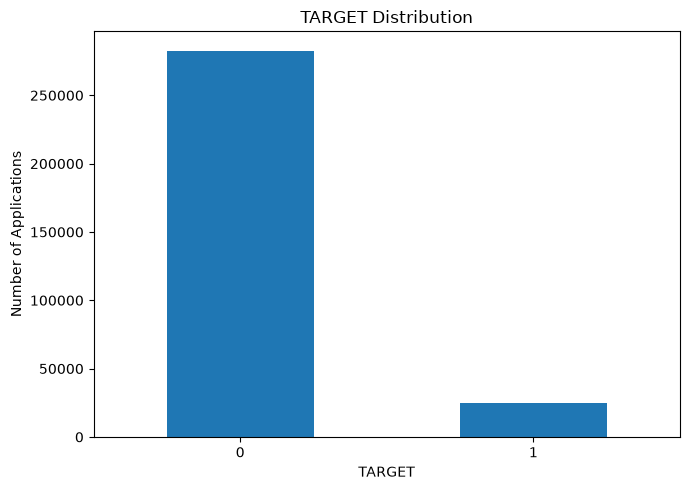

In [8]:
import matplotlib.pyplot as plt

ax = target_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

ax.set_title("TARGET Distribution")
ax.set_xlabel("TARGET")
ax.set_ylabel("Number of Applications")
ax.set_xticklabels(["0", "1"], rotation=0)

plt.tight_layout()
plt.show()

In [9]:
negative_count = target_counts[0]
positive_count = target_counts[1]

imbalance_ratio = negative_count / positive_count

print(f"TARGET 0 / TARGET 1 ratio: {imbalance_ratio:.2f}:1")

TARGET 0 / TARGET 1 ratio: 11.39:1


In [10]:
description_file = DATA_DIR / "HomeCredit_columns_description.csv"

column_descriptions = pd.read_csv(
    description_file,
    encoding="cp1252"
)

column_descriptions.head(10)

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
5,8,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN
6,9,application_{train|test}.csv,CNT_CHILDREN,Number of children the client has,NaN
7,10,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,NaN
8,11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,NaN
9,12,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,NaN


In [11]:
# Gereksiz CSV index kolonunu kaldırıyoruz.
column_descriptions = column_descriptions.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

# Sadece application_train / application_test kolon açıklamalarını seçiyoruz.
application_dictionary = (
    column_descriptions[
        column_descriptions["Table"]
        .astype(str)
        .str.contains("application_", case=False, na=False)
    ]
    [["Row", "Description", "Special"]]
    .reset_index(drop=True)
)

application_dictionary.head(20)

,Row,Description,Special
0,SK_ID_CURR,ID of loan in our sample,NaN
1,TARGET,Target variable (1 - client with payment diffi...,NaN
2,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,CODE_GENDER,Gender of the client,NaN
4,FLAG_OWN_CAR,Flag if the client owns a car,NaN
5,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN
6,CNT_CHILDREN,Number of children the client has,NaN
7,AMT_INCOME_TOTAL,Income of the client,NaN
8,AMT_CREDIT,Credit amount of the loan,NaN
9,AMT_ANNUITY,Loan annuity,NaN


In [12]:
print(f"Application dictionary rows: {len(application_dictionary)}")
print(f"Application train columns: 122")

Application dictionary rows: 122
Application train columns: 122


In [13]:
application_sample = pd.read_csv(
    DATA_DIR / "application_train.csv",
    nrows=5000
)

numeric_columns = application_sample.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = application_sample.select_dtypes(
    exclude=["number"]
).columns.tolist()

print(f"Total columns: {application_sample.shape[1]}")
print(f"Numeric columns: {len(numeric_columns)}")
print(f"Categorical columns: {len(categorical_columns)}")

Total columns: 122
Numeric columns: 106
Categorical columns: 16


In [14]:
categorical_summary = []

for column in categorical_columns:
    categorical_summary.append({
        "column": column,
        "unique_values": application_sample[column].nunique(dropna=True),
        "missing_count": application_sample[column].isna().sum()
    })

categorical_summary_df = pd.DataFrame(categorical_summary)

categorical_summary_df.sort_values(
    "unique_values",
    ascending=False
).reset_index(drop=True)

,column,unique_values,missing_count
0,ORGANIZATION_TYPE,58,0
1,OCCUPATION_TYPE,18,1545
2,NAME_TYPE_SUITE,7,20
3,WEEKDAY_APPR_PROCESS_START,7,0
4,WALLSMATERIAL_MODE,7,2483
5,NAME_HOUSING_TYPE,6,0
6,NAME_INCOME_TYPE,5,0
7,NAME_FAMILY_STATUS,5,0
8,NAME_EDUCATION_TYPE,5,0
9,FONDKAPREMONT_MODE,4,3351


In [15]:
missing_counts = None
total_rows = 0

for chunk in pd.read_csv(
    DATA_DIR / "application_train.csv",
    chunksize=50_000
):
    chunk_missing = chunk.isna().sum()

    if missing_counts is None:
        missing_counts = chunk_missing
    else:
        missing_counts = missing_counts.add(
            chunk_missing,
            fill_value=0
        )

    total_rows += len(chunk)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts.astype(int),
    "missing_percentage": (
        missing_counts / total_rows * 100
    )
})

missing_summary = (
    missing_summary
    .sort_values(
        "missing_percentage",
        ascending=False
    )
)

print(f"Total rows analysed: {total_rows:,}")

missing_summary.head(20)

Total rows analysed: 307,511


,missing_count,missing_percentage
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [16]:
def missing_group(percentage):
    if percentage == 0:
        return "No missing"
    elif percentage < 10:
        return "Low (<10%)"
    elif percentage < 30:
        return "Moderate (10-30%)"
    elif percentage < 50:
        return "High (30-50%)"
    else:
        return "Very high (>=50%)"


missing_summary["missing_group"] = (
    missing_summary["missing_percentage"]
    .apply(missing_group)
)

missing_group_summary = (
    missing_summary["missing_group"]
    .value_counts()
    .reindex([
        "No missing",
        "Low (<10%)",
        "Moderate (10-30%)",
        "High (30-50%)",
        "Very high (>=50%)"
    ])
    .fillna(0)
    .astype(int)
)

missing_group_summary

missing_group
No missing           55
Low (<10%)           10
Moderate (10-30%)     7
High (30-50%)         9
Very high (>=50%)    41
Name: count, dtype: int64

In [17]:
numeric_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED"
]

numeric_df = pd.read_csv(
    DATA_DIR / "application_train.csv",
    usecols=numeric_features
)

numeric_df.describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0


In [18]:
outlier_check = pd.DataFrame({
    "check": [
        "Income > 1,000,000",
        "DAYS_EMPLOYED == 365243",
        "Missing AMT_ANNUITY"
    ],
    "count": [
        (numeric_df["AMT_INCOME_TOTAL"] > 1_000_000).sum(),
        (numeric_df["DAYS_EMPLOYED"] == 365243).sum(),
        numeric_df["AMT_ANNUITY"].isna().sum()
    ]
})

outlier_check

,check,count
0,"Income > 1,000,000",250
1,DAYS_EMPLOYED == 365243,55374
2,Missing AMT_ANNUITY,12


In [19]:
age_years = -numeric_df["DAYS_BIRTH"] / 365.25

print(f"Minimum age: {age_years.min():.1f}")
print(f"Median age: {age_years.median():.1f}")
print(f"Maximum age: {age_years.max():.1f}")

Minimum age: 20.5
Median age: 43.1
Maximum age: 69.1


In [20]:
total_applications = len(numeric_df)

outlier_percentages = pd.DataFrame({
    "check": [
        "Income > 1,000,000",
        "DAYS_EMPLOYED == 365243",
        "Missing AMT_ANNUITY"
    ],
    "count": [
        (numeric_df["AMT_INCOME_TOTAL"] > 1_000_000).sum(),
        (numeric_df["DAYS_EMPLOYED"] == 365243).sum(),
        numeric_df["AMT_ANNUITY"].isna().sum()
    ]
})

outlier_percentages["percentage"] = (
    outlier_percentages["count"]
    / total_applications
    * 100
)

outlier_percentages

,check,count,percentage
0,"Income > 1,000,000",250,0.081298
1,DAYS_EMPLOYED == 365243,55374,18.007161
2,Missing AMT_ANNUITY,12,0.003902


In [21]:
employment_target_df = pd.read_csv(
    DATA_DIR / "application_train.csv",
    usecols=["DAYS_EMPLOYED", "TARGET"]
)

employment_target_df["employment_anomaly"] = (
    employment_target_df["DAYS_EMPLOYED"] == 365243
)

employment_anomaly_analysis = (
    employment_target_df
    .groupby("employment_anomaly")["TARGET"]
    .agg(
        applications="count",
        target_rate="mean"
    )
)

employment_anomaly_analysis["target_rate_percentage"] = (
    employment_anomaly_analysis["target_rate"] * 100
)

employment_anomaly_analysis

,applications,target_rate,target_rate_percentage
employment_anomaly,,,
False,252137,0.086600,8.659975
True,55374,0.053996,5.399646


In [22]:
income_percentiles = (
    numeric_df["AMT_INCOME_TOTAL"]
    .quantile([
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
        0.995,
        0.999,
        1.00
    ])
)

income_percentiles

0.500       147150.0
0.750       202500.0
0.900       270000.0
0.950       337500.0
0.990       472500.0
0.995       630000.0
0.999       900000.0
1.000    117000000.0
Name: AMT_INCOME_TOTAL, dtype: float64

In [23]:
top_income_cases = (
    numeric_df[
        numeric_df["AMT_INCOME_TOTAL"] > 1_000_000
    ]
    ["AMT_INCOME_TOTAL"]
    .sort_values(ascending=False)
    .head(20)
)

top_income_cases

12840     117000000.0
203693     18000090.0
246858     13500000.0
77768       9000000.0
131127      6750000.0
103006      4500000.0
187833      4500000.0
204564      4500000.0
287463      4500000.0
181698      3950059.5
20216       3825000.0
284311      3600000.0
49645       3600000.0
86026       3375000.0
82846       3375000.0
248159      3150000.0
101007      3150000.0
107926      2930026.5
258773      2700000.0
298082      2475000.0
Name: AMT_INCOME_TOTAL, dtype: float64

In [24]:
target_features = pd.read_csv(
    DATA_DIR / "application_train.csv",
    usecols=[
        "TARGET",
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "DAYS_BIRTH"
    ]
)

target_features["AGE_YEARS"] = (
    -target_features["DAYS_BIRTH"] / 365.25
)

target_group_summary = (
    target_features
    .groupby("TARGET")[
        [
            "AMT_INCOME_TOTAL",
            "AMT_CREDIT",
            "AMT_ANNUITY",
            "AGE_YEARS"
        ]
    ]
    .median()
)

target_group_summary

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AGE_YEARS
TARGET,,,,
0,148500.0,517788.0,24876.0,43.468857
1,135000.0,497520.0,25263.0,39.101985


In [25]:
target_features["AGE_GROUP"] = pd.cut(
    target_features["AGE_YEARS"],
    bins=[20, 30, 40, 50, 60, 70],
    labels=[
        "20-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69"
    ],
    right=False
)

age_risk = (
    target_features
    .groupby(
        "AGE_GROUP",
        observed=False
    )["TARGET"]
    .agg(
        applications="count",
        target_rate="mean"
    )
)

age_risk["target_rate_percentage"] = (
    age_risk["target_rate"] * 100
)

age_risk

,applications,target_rate,target_rate_percentage
AGE_GROUP,,,
20-29,45186,0.114438,11.443810
30-39,82331,0.095918,9.591770
40-49,76599,0.076411,7.641092
50-59,68094,0.061210,6.120950
60-69,35301,0.049177,4.917708


In [26]:
categorical_target_df = pd.read_csv(
    DATA_DIR / "application_train.csv",
    usecols=[
        "TARGET",
        "NAME_CONTRACT_TYPE",
        "NAME_EDUCATION_TYPE",
        "NAME_INCOME_TYPE"
    ]
)

In [27]:
contract_risk = (
    categorical_target_df
    .groupby("NAME_CONTRACT_TYPE")["TARGET"]
    .agg(
        applications="count",
        target_rate="mean"
    )
    .sort_values("target_rate", ascending=False)
)

contract_risk["target_rate_percentage"] = (
    contract_risk["target_rate"] * 100
)

contract_risk

,applications,target_rate,target_rate_percentage
NAME_CONTRACT_TYPE,,,
Cash loans,278232,0.083459,8.345913
Revolving loans,29279,0.054783,5.478329


In [28]:
education_risk = (
    categorical_target_df
    .groupby("NAME_EDUCATION_TYPE")["TARGET"]
    .agg(
        applications="count",
        target_rate="mean"
    )
    .sort_values("target_rate", ascending=False)
)

education_risk["target_rate_percentage"] = (
    education_risk["target_rate"] * 100
)

education_risk

,applications,target_rate,target_rate_percentage
NAME_EDUCATION_TYPE,,,
Lower secondary,3816,0.109277,10.927673
Secondary / secondary special,218391,0.089399,8.939929
Incomplete higher,10277,0.084850,8.484966
Higher education,74863,0.053551,5.355115
Academic degree,164,0.018293,1.829268


In [29]:
income_type_risk = (
    categorical_target_df
    .groupby("NAME_INCOME_TYPE")["TARGET"]
    .agg(
        applications="count",
        target_rate="mean"
    )
    .sort_values("target_rate", ascending=False)
)

income_type_risk["target_rate_percentage"] = (
    income_type_risk["target_rate"] * 100
)

income_type_risk

,applications,target_rate,target_rate_percentage
NAME_INCOME_TYPE,,,
Maternity leave,5,0.400000,40.000000
Unemployed,22,0.363636,36.363636
Working,158774,0.095885,9.588472
Commercial associate,71617,0.074843,7.484257
State servant,21703,0.057550,5.754965
Pensioner,55362,0.053864,5.386366
Businessman,10,0.000000,0.000000
Student,18,0.000000,0.000000


In [30]:
correlation_columns = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

corr_df = pd.read_csv(
    DATA_DIR / "application_train.csv",
    usecols=correlation_columns
)

corr_df.head()

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,1,202500.0,406597.5,24700.5,-9461,-637,0.083037,0.262949,0.139376
1,0,270000.0,1293502.5,35698.5,-16765,-1188,0.311267,0.622246,NaN
2,0,67500.0,135000.0,6750.0,-19046,-225,NaN,0.555912,0.729567
3,0,135000.0,312682.5,29686.5,-19005,-3039,NaN,0.650442,NaN
4,0,121500.0,513000.0,21865.5,-19932,-3038,NaN,0.322738,NaN


In [31]:
corr_df["AGE_YEARS"] = -corr_df["DAYS_BIRTH"] / 365.25

corr_df["DAYS_EMPLOYED_ANOMALY"] = (
    corr_df["DAYS_EMPLOYED"] == 365243
).astype(int)

corr_df.loc[
    corr_df["DAYS_EMPLOYED"] == 365243,
    "DAYS_EMPLOYED"
] = np.nan

In [33]:
target_correlations = (
    corr_df
    .corr(numeric_only=True)["TARGET"]
    .drop("TARGET")
    .sort_values(key=abs, ascending=False)
)

target_correlations

EXT_SOURCE_3            -0.178919
EXT_SOURCE_2            -0.160472
EXT_SOURCE_1            -0.155317
AGE_YEARS               -0.078239
DAYS_BIRTH               0.078239
DAYS_EMPLOYED            0.074958
DAYS_EMPLOYED_ANOMALY   -0.045987
AMT_CREDIT              -0.030369
AMT_ANNUITY             -0.012817
AMT_INCOME_TOTAL        -0.003982
Name: TARGET, dtype: float64

In [34]:
selected_corr = corr_df[
    [
        "TARGET",
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "AGE_YEARS",
        "DAYS_EMPLOYED",
        "DAYS_EMPLOYED_ANOMALY",
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3"
    ]
].corr()

selected_corr.round(3)

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AGE_YEARS,DAYS_EMPLOYED,DAYS_EMPLOYED_ANOMALY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
TARGET,1.000,-0.004,-0.030,-0.013,-0.078,0.075,-0.046,-0.155,-0.160,-0.179
AMT_INCOME_TOTAL,-0.004,1.000,0.157,0.192,-0.027,-0.013,-0.064,0.026,0.061,-0.030
AMT_CREDIT,-0.030,0.157,1.000,0.770,0.055,-0.091,-0.066,0.168,0.131,0.044
AMT_ANNUITY,-0.013,0.192,0.770,1.000,-0.009,-0.054,-0.104,0.119,0.126,0.031
AGE_YEARS,-0.078,-0.027,0.055,-0.009,1.000,-0.352,0.620,0.601,0.092,0.205
DAYS_EMPLOYED,0.075,-0.013,-0.091,-0.054,-0.352,1.000,NaN,-0.253,-0.093,-0.130
DAYS_EMPLOYED_ANOMALY,-0.046,-0.064,-0.066,-0.104,0.620,NaN,1.000,0.294,-0.020,0.115
EXT_SOURCE_1,-0.155,0.026,0.168,0.119,0.601,-0.253,0.294,1.000,0.214,0.187
EXT_SOURCE_2,-0.160,0.061,0.131,0.126,0.092,-0.093,-0.020,0.214,1.000,0.109
EXT_SOURCE_3,-0.179,-0.030,0.044,0.031,0.205,-0.130,0.115,0.187,0.109,1.000


In [35]:
train_columns = set(
    pd.read_csv(
        DATA_DIR / "application_train.csv",
        nrows=0
    ).columns
)

test_columns = set(
    pd.read_csv(
        DATA_DIR / "application_test.csv",
        nrows=0
    ).columns
)

only_in_train = sorted(train_columns - test_columns)
only_in_test = sorted(test_columns - train_columns)

print("Only in train:")
print(only_in_train)

print("\nOnly in test:")
print(only_in_test)

Only in train:
['TARGET']

Only in test:
[]


In [36]:
suspicious_keywords = [
    "TARGET",
    "DEFAULT",
    "OUTCOME",
    "RESULT",
    "REPAY",
    "PAYMENT_DIFFICULT",
    "BAD_LOAN"
]

suspicious_columns = [
    column
    for column in train_columns
    if any(
        keyword in column.upper()
        for keyword in suspicious_keywords
    )
]

suspicious_columns

['TARGET']

In [37]:
identifier_columns = [
    column
    for column in train_columns
    if column.startswith("SK_ID")
]

identifier_columns

['SK_ID_CURR']